In [3]:
# Install dependencies for this notebook

try:
    import uproot, awkward, hist
except ModuleNotFoundError:
    import sys
    if sys.platform.startswith("emscripten"):
        import micropip
        await micropip.install("awkward==2.8.5")
        await micropip.install("uproot")
        await micropip.install("hist")
    else:
        %pip install uproot awkward hist

# Let's start by looking at our first tool from Scikit-HEP

:::{figure} ./images/uproot_logo.png
:align: center
:width: 30%
:::

Uproot is a Python package that reads and writes ROOT files.

Uproot is only concerned with ROOT I/O. Once it reads the data, it passes it on to NumPy/Awkward/Pandas for data manipulations, to boost-histogram/hist for histogram manipulations, to Vector for Lorentz vector manipulations, etc.

:::{figure} ./images/skhep-stack.png
:align: center
:width: 60%
:::

Similarly, it takes input from these other packages to write them into a ROOT file.

# Reading data from a file

In [103]:
# Download a few files that we will use

import requests
from pathlib import Path

url_prefix = "https://raw.githubusercontent.com/scikit-hep/scikit-hep-testdata/refs/heads/main/src/skhep_testdata/data/"

files = [
    "ntpl001_staff_rntuple_v1-0-0-0.root",
    "uproot-Event.root",
    "uproot-issue283.root",
    "test_stl_containers_rntuple_v1-0-0-0.root",
    "uproot-Zmumu.root",
]

datadir = Path("data")
datadir.mkdir(exist_ok=True)

for file in files:
    response = requests.get(url_prefix + file)
    
    if response.status_code == 200:
        with open(datadir / file, "wb") as f:
            f.write(response.content)
    else:
        print(f"Failed to download {file}")

## Opening a file

To open a file for reading, pass the name of the file to [uproot.open](https://uproot.readthedocs.io/en/latest/uproot.reading.open.html). In scripts, it is good practice to use [Python’s `with` statement](https://realpython.com/python-with-statement/) to close the file when you’re done, but if you’re working interactively, you can use a direct assignment.

In [32]:
import uproot

file = uproot.open("data/uproot-Event.root")

To access a remote file via HTTP or XRootD, use a `"http://..."`, `"https://..."`, or `"root://..."` URL. If the Python interface to XRootD is not installed, the error message will explain how to install it.

On JupyterLite, we are more limited, so that's why we downloaded the files beforehand.

## Listing contents

This `file` object actually represents a directory, and the named objects in that directory are accessible with a dict-like interface. Thus, `keys`, `values`, and `items` return the key names and/or read the data. If you want to just list the objects without reading, use `keys`. (This is like ROOT’s `ls()`, except that you get a Python list.)

In [33]:
file.keys()

['ProcessID0;1', 'htime;1', 'T;1', 'hstat;1']

Often, you want to know the type of each object as well, so [uproot.ReadOnlyDirectory](https://uproot.readthedocs.io/en/latest/uproot.reading.ReadOnlyDirectory.html) objects also have a `classnames` method, which returns a dict of object names to class names (without reading them).

In [34]:
file.classnames()

{'ProcessID0;1': 'TProcessID',
 'htime;1': 'TH1F',
 'T;1': 'TTree',
 'hstat;1': 'TH1F'}

## Reading a histogram

If you’re familiar with ROOT, `TH1F` would be recognizable as histograms and `TTree` would be recognizable as a dataset. To read one of the histograms, put its name in square brackets:

In [35]:
h = file["hstat"]
h

<TH1F (version 2) at 0x00016e3fbcb0>

Uproot doesn’t do any plotting or histogram manipulation, so the most useful methods of `h` begin with “to”: `to_boost` (boost-histogram), `to_hist` (hist), `to_numpy` (NumPy’s 2-tuple of contents and edges), `to_pyroot` (PyROOT), etc.

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x17782c890>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

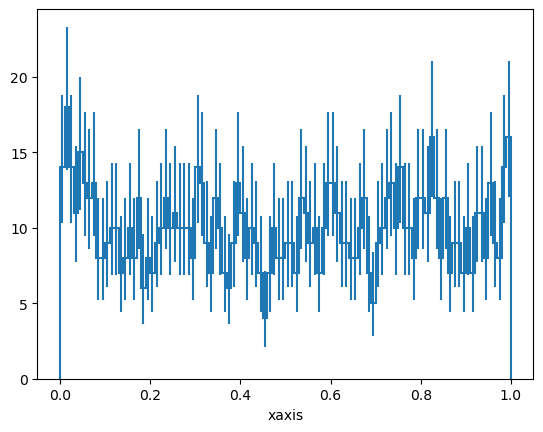

In [36]:
h.to_hist().plot()

Uproot histograms also satisfy the [UHI plotting protocol](https://uhi.readthedocs.io/en/latest/plotting.html), so they have methods like `values` (bin contents), `variances` (errors squared), and `axes`.

In [37]:
h.values()

array([14., 18., 14., 11., 15., 13., 12., 13.,  8.,  8.,  9., 10., 10.,
        7.,  8., 10.,  8., 12.,  6.,  8.,  7.,  9., 10., 12., 10., 11.,
       10., 10., 10.,  8., 14., 13.,  9.,  7., 12., 10.,  7.,  6.,  9.,
       13., 11.,  8., 10.,  9.,  7.,  4.,  7., 10.,  8.,  8.,  9.,  9.,
        7., 12., 11.,  9., 10.,  7., 10., 13., 13., 11.,  9.,  9.,  8.,
        8., 10., 12.,  7.,  5.,  9., 10., 12., 13., 10., 14., 10., 10.,
        8., 12., 12., 11., 16., 12.,  8., 12.,  7.,  9.,  9.,  7., 10.,
        7., 11., 11.,  8., 13.,  9.,  8., 14., 16.], dtype=float32)

In [38]:
h.variances()

array([14., 18., 14., 11., 15., 13., 12., 13.,  8.,  8.,  9., 10., 10.,
        7.,  8., 10.,  8., 12.,  6.,  8.,  7.,  9., 10., 12., 10., 11.,
       10., 10., 10.,  8., 14., 13.,  9.,  7., 12., 10.,  7.,  6.,  9.,
       13., 11.,  8., 10.,  9.,  7.,  4.,  7., 10.,  8.,  8.,  9.,  9.,
        7., 12., 11.,  9., 10.,  7., 10., 13., 13., 11.,  9.,  9.,  8.,
        8., 10., 12.,  7.,  5.,  9., 10., 12., 13., 10., 14., 10., 10.,
        8., 12., 12., 11., 16., 12.,  8., 12.,  7.,  9.,  9.,  7., 10.,
        7., 11., 11.,  8., 13.,  9.,  8., 14., 16.])

In [39]:
list(h.axes[0])  # "x", "y", "z" or 0, 1, 2

[array([0.  , 0.01]),
 array([0.01, 0.02]),
 array([0.02, 0.03]),
 array([0.03, 0.04]),
 array([0.04, 0.05]),
 array([0.05, 0.06]),
 array([0.06, 0.07]),
 array([0.07, 0.08]),
 array([0.08, 0.09]),
 array([0.09, 0.1 ]),
 array([0.1 , 0.11]),
 array([0.11, 0.12]),
 array([0.12, 0.13]),
 array([0.13, 0.14]),
 array([0.14, 0.15]),
 array([0.15, 0.16]),
 array([0.16, 0.17]),
 array([0.17, 0.18]),
 array([0.18, 0.19]),
 array([0.19, 0.2 ]),
 array([0.2 , 0.21]),
 array([0.21, 0.22]),
 array([0.22, 0.23]),
 array([0.23, 0.24]),
 array([0.24, 0.25]),
 array([0.25, 0.26]),
 array([0.26, 0.27]),
 array([0.27, 0.28]),
 array([0.28, 0.29]),
 array([0.29, 0.3 ]),
 array([0.3 , 0.31]),
 array([0.31, 0.32]),
 array([0.32, 0.33]),
 array([0.33, 0.34]),
 array([0.34, 0.35]),
 array([0.35, 0.36]),
 array([0.36, 0.37]),
 array([0.37, 0.38]),
 array([0.38, 0.39]),
 array([0.39, 0.4 ]),
 array([0.4 , 0.41]),
 array([0.41, 0.42]),
 array([0.42, 0.43]),
 array([0.43, 0.44]),
 array([0.44, 0.45]),
 array([0.

## Reading a TTree

A TTree represents a potentially large dataset. Getting it from the [`uproot.ReadOnlyDirectory`](https://uproot.readthedocs.io/en/latest/uproot.reading.ReadOnlyDirectory.html) only returns its TBranch names and types. The `show` method is a convenient way to list its contents:

In [40]:
t = file["T"]
t.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
event                | Event                    | AsGroup(<TBranchElement 'ev...
event/TObject        | (group of fUniqueID:u... | AsGroup(<TBranchElement 'TO...
event/TObject/fUn... | uint32_t                 | AsDtype('>u4')
event/TObject/fBits  | uint32_t                 | AsDtype('>u4')
event/fType[20]      | int8_t[20]               | AsDtype("('i1', (20,))")
event/fEventName     | char*                    | AsStrings(length_bytes='4')
event/fNtrack        | int32_t                  | AsDtype('>i4')
event/fNseg          | int32_t                  | AsDtype('>i4')
event/fNvertex       | uint32_t                 | AsDtype('>u4')
event/fFlag          | uint32_t                 | AsDtype('>u4')
event/fTemperature   | float                    | AsDtype('>f4', 'float64')
event/fMeasures[10]  | int32_t[10]              | AsDtype

Be aware that you can get the same information from `keys` (an [uproot.TTree](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TTree.TTree.html) is dict-like), `typename`, and `interpretation`.

In [41]:
last_key = t.keys()[-1]
last_key, t[last_key].typename, t[last_key].interpretation

('event/fIsValid', 'bool', AsDtype('bool'))

(If an [`uproot.TBranch`](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TBranch.TBranch.html) has no `interpretation`, it can’t be read by Uproot.)

The most direct way to read data from an [uproot.TBranch](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TBranch.TBranch.html) is by calling its `array` method.

In [42]:
t["event/fNtrack"].array()

<Array [600, 604, 603, 594, 595, ..., 598, 600, 596, 593] type='1000 * int32'>

## Reading a… what is that?

This file also contains an instance of type [TProcessID](https://root.cern.ch/doc/master/classTProcessID.html). These aren’t typically useful in data analysis, but Uproot manages to read it anyway because it follows certain conventions (it has “class streamers”). It’s presented as a generic object with an `all_members` property for its data members (through all superclasses).

In [43]:
print(file["ProcessID0"])
print(file["ProcessID0"].all_members)

<TProcessID (version 1) at 0x000177e6df10>
{'@fUniqueID': 0, '@fBits': 50331648, 'fName': 'ProcessID0', 'fTitle': '3ec87674-3aa2-11e9-bb02-0301a8c0beef'}


Here’s a more useful example of that: a supernova search with the IceCube experiment has custom classes for its data, which Uproot reads and represents as objects with `all_members`.

In [44]:
icecube = uproot.open("data/uproot-issue283.root")
icecube.classnames()

{'config;1': 'TDirectory',
 'config/analysis;1': 'SN_Analysis_Configuration_t',
 'config/detector;1': 'I3Eval_t',
 'config/run;1': 'SN_File_t',
 'sn_all;1': 'TTree',
 'sn_gps;1': 'TTree',
 'sn_range;1': 'TTree',
 'sn_o2rout;1': 'TTree',
 'sn_o2cand;1': 'TTree',
 'sn_omwatch;1': 'TTree',
 'sn_sigsim;1': 'TTree'}

In [45]:
icecube["config/detector"].all_members

{'@fUniqueID': 0,
 '@fBits': 50331648,
 'theDataArray': <Sni3DataArray (version 1) at 0x000177e6e480>,
 'NumberOfChannels': 5160,
 'NoAvailableSlices': -1,
 'AvailableDataSize': 0,
 'mGPSCardId': 0,
 'mGPSPrescale': 20000000,
 'mGPSEventNo': 92824,
 'mScalerCardId': 0,
 'mScalerStartChannel': 0,
 'StartUTC': 272924620173109013,
 'MaxChannels': 5160,
 'mMaxJitterLogs': 20,
 'Channel': <I3Eval_t::ChannelContainer_t (version 1) at 0x000177adc980>,
 'ChannelIDMap': <STLMap {46612627560: 896, ..., 281410180683757: 2689} at 0x000177b33560>,
 'BadChannelIDSet': <STLSet {58348614635591, 60068372029697, ..., 258905191174588} at 0x000177b33260>,
 'ChannelID': array([ 47303335284587,  20579555797555, 106634453247646, ...,
        255380957221937, 107432791511293, 280205879548048],
       shape=(5160,), dtype='>i8'),
 'Deadtime': array([250., 250., 250., ..., 250., 250., 250.],
       shape=(5160,), dtype='>f8'),
 'Efficiency': array([1.  , 1.  , 1.  , ..., 1.35, 1.35, 1.35],
       shape=(5160,),

In [46]:
icecube["config/detector"].all_members["ChannelIDMap"]

<STLMap {46612627560: 896, ..., 281410180683757: 2689} at 0x000177b33560>

# Writing data to a file

Uproot’s ability to *write* data is more limited than its ability to *read* data, but it can write most things you might be interested in writing.

## Opening files for writing

First of all, a file must be opened for writing, either by creating a completely new file or updating an existing one.

In [47]:
output1 = uproot.recreate("completely-new-file.root")
# output2 = uproot.update("existing-file.root")

(Uproot cannot write over a network; output files must be local.)

## Writing strings and histograms

These uproot.WritableDirectory objects have a dict-like interface: you can put data in them by assigning to square brackets.

In [48]:
output1["some_string"] = "This will be a TObjString."

output1["some_histogram"] = file["hstat"]

import numpy as np

output1["nested_directory/another_histogram"] = np.histogram(
    np.random.normal(0, 1, 1000000)
)

In ROOT, the name of an object is a property of the object, but in Uproot, it’s a key in the TDirectory that holds the object, so that’s why the name is on the left-hand side of the assignment, in square brackets. Only the data types listed in the blue box [in the documentation](https://uproot.readthedocs.io/en/latest/basic.html#writing-objects-to-a-file) are supported: mostly just histograms.

## Writing TTrees

TTrees are potentially large and might not fit in memory. Generally, you’ll need to write them in batches. One way to do this is to assign the first batch and extend it with subsequent batches.

**Important note:** The syntax `file["name"] = numerical_data` used to write a TTree. However, this changed recently and will now write an RNTuple instead (see below).

In [52]:
import numpy as np

output1.mktree("tree1",
    {
        "x": np.random.randint(0, 10, 1000000),
        "y": np.random.normal(0, 1, 1000000),
    }
)
output1["tree1"].extend(
    {"x": np.random.randint(0, 10, 1000000), "y": np.random.normal(0, 1, 1000000)}
)
output1["tree1"].extend(
    {"x": np.random.randint(0, 10, 1000000), "y": np.random.normal(0, 1, 1000000)}
)

another is to create an empty TTree with [uproot.WritableDirectory.mktree](https://uproot.readthedocs.io/en/latest/uproot.writing.writable.WritableDirectory.html#mktree), so that every write is an extension.

In [53]:
output1.mktree("tree2", {"x": np.int32, "y": np.float64})
output1["tree2"].extend(
    {"x": np.random.randint(0, 10, 1000000), "y": np.random.normal(0, 1, 1000000)}
)
output1["tree2"].extend(
    {"x": np.random.randint(0, 10, 1000000), "y": np.random.normal(0, 1, 1000000)}
)
output1["tree2"].extend(
    {"x": np.random.randint(0, 10, 1000000), "y": np.random.normal(0, 1, 1000000)}
)

In general, it pays to write few large batches, rather than many small batches.

The only data types that can be assigned or passed to `extend` are listed in the blue box [in this documentation](https://uproot.readthedocs.io/en/latest/basic.html#writing-ttrees-to-a-file). This includes jagged arrays, but not more complex types.

## Reading and writing RNTuples

TTree has been the default format to store large datasets in ROOT files for decades. However, it has slowly become outdated and are not optimized for modern systems. This is where the RNTuple format comes in. It is a modern serialization format that is designed with modern systems in mind and is planned to replace TTree in the coming years. Version [1.0.0.0](https://cds.cern.ch/record/2923186) is out and will be supported “forever”.

RNTuples are much simpler than TTrees by design, and this time there is an official specification, which makes it much easier for third-party I/O packages like Uproot to support. Uproot already supports reading the full RNTuple specification, meaning that you can read any RNTuple you find in the wild. It also supports writing a large part of the specification, and intends to support as much as it makes sense for data analysis.

To ease the transition into RNTuples, we are designing the interface to match the one for TTrees as closely as possible. Let’s look at a simple example for reading and writing RNTuples.

In [61]:
file = uproot.open("data/test_stl_containers_rntuple_v1-0-0-0.root")

This time, if we print the class names, we see that there is an RNTuple instead of a TTree.

In [62]:
file.classnames()

{'ntuple;1': 'ROOT::RNTuple'}

In [63]:
rntuple = file["ntuple"]
rntuple.keys(recursive=False)

['string',
 'vector_int32',
 'array_float',
 'vector_vector_int32',
 'vector_string',
 'vector_vector_string',
 'variant_int32_string',
 'vector_variant_int64_string',
 'tuple_int32_string',
 'pair_int32_string',
 'vector_tuple_int32_string',
 'lorentz_vector',
 'array_lv']

In [64]:
rntuple["vector_int32"].array()

<Array [[1], [1, 2], ..., [1, ..., 4], [1, 2, 3, 4, 5]] type='5 * var * int32'>

Writing again works in a very similar way to TTrees. However, since TTrees are still the default format used in more places, writing something like `file[key] = data` will default to writing the data as a TTree (but this will change in about 6 months!).

For now, when we want to write an RNTuple, we need to specifically tell Uproot that we want to do so.

In [65]:
data = {"my_int_data": [1, 2, 3], "my_float_data": [1.0, 2.0, 3.0]}
more_data = {"my_int_data": [4, 5, 6], "my_float_data": [4.0, 5.0, 6.0]}

output3 = uproot.recreate("new-file-with-rntuple.root")

output3["my_rntuple"] = data
output3["my_rntuple"].extend(more_data)

/var/folders/9p/yztwhyvx5r99jr0kvf1m721m0000gq/T/ipykernel_70513/3287847592.py:6: FutureWarning: Starting in version 5.7.0, Uproot will default to writing RNTuples instead of TTrees. You will need to use `mktree` to explicitly create a TTree. This can be done by changing `file['tree_name'] = data` to `file.mktree('tree_name', data)`. Please update your code accordingly.
  output3["my_rntuple"] = data


For the rest of the tutorial we will mostly focus on TTrees since this is still the main data format that you’ll encounter for now.

## Exercise

There is a file in the data directory named `"ntpl001_staff_rntuple_v1-0-0-0.root"` that contains CERN staff data from 1988. As the name suggests, it is an RNTuple and not a TTree.

1.  Open it with Uproot, look around at what's in there, and then find the number of French employees who were at least 35 years old, and had one or two children. For bonus points, use `with uproot.open(...) as f:` instead of `f = uproot.open(...)` to follow best practices.
2.  With the selection from the previous part, make a histogram of the employee grade with `np.histogram(np.array(data))`, and save it to a new ROOT file. (You need to wrap the data with `np.array` due to a bug I found while writing this.)
3.  Read back the file you just made. Open the histogram, use `to_hist()` to convert it to a `hist` histogram, and then plot it with `.plot()`.

:::{note} Answer (Don't look until you're done)
:class: dropdown

```python
import skhep_testdata
import uproot
import numpy as np

with uproot.open("data/ntpl001_staff_rntuple_v1-0-0-0.root") as file:
    staff = file["Staff"]
    staff_age = staff["Age"].array()
    staff_nation = staff["Nation"].array()
    staff_children = staff["Children"].array()
    staff_grade = staff["Grade"].array()

cut = (staff_nation == "FR") \
    & (staff_age >= 35) \
    & (1 <= staff_children) \
    & (2 >= staff_children)

n = len(staff_age[cut])

n = np.sum(cut) # A simpler alternative is to sum count the number of True values in cut

print(f"The number of employees with the selected criteria is {n}")

with uproot.recreate("my_file.root") as file:
    file["my_hist"] = np.histogram(np.array(staff_grade[cut]))

with uproot.open("my_file.root") as file:
    h = file["my_hist"].to_hist()

h.plot()
```
:::

In [ ]:
# Write your code here


# ROOT file structure and terminology

A ROOT file ([ROOT `TFile`](https://root.cern.ch/doc/master/classTFile.html), [`uproot.ReadOnlyFile`](https://uproot.readthedocs.io/en/latest/uproot.reading.ReadOnlyFile.html)) is like a little filesystem containing nested directories ([ROOT `TDirectory`](https://root.cern.ch/doc/master/classTDirectory.html), [`uproot.ReadOnlyDirectory`](https://uproot.readthedocs.io/en/latest/uproot.reading.ReadOnlyDirectory.html)). In Uproot, nested directories are presented as nested dicts.

Any class instance ([ROOT `TObject`](https://root.cern.ch/doc/master/classTObject.html), [`uproot.Model`](https://uproot.readthedocs.io/en/latest/uproot.model.Model.html)) can be stored in a directory, including types such as histograms (e.g. [ROOT `TH1`](https://root.cern.ch/doc/master/classTH1.html), [`uproot.behaviors.TH1.TH1`](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TH1.TH1.html)).

One of these classes, TTree ([ROOT TTree](https://root.cern.ch/doc/master/classTTree.html), [`uproot.TTree`](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TTree.TTree.html)), is a gateway to large datasets. A TTree is roughly like a Pandas DataFrame in that it represents a table of data. The columns are called TBranches ([`ROOT TBranch`](https://root.cern.ch/doc/master/classTBranch.html), [`uproot.TBranch`](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TBranch.TBranch.html)), which can be nested (unlike Pandas), and the data can have any C++ type (unlike Pandas, which can store any Python type).

A TTree is often too large to fit in memory, and sometimes (rarely) even a single TBranch is too large to fit in memory. Each TBranch is therefore broken down into TBaskets ([`ROOT TBasket`](https://root.cern/doc/master/classTBasket.html), [`uproot.models.TBasket.Model_TBasket`](https://uproot.readthedocs.io/en/latest/uproot.models.TBasket.Model_TBasket.html)), which are "batches" of data. (These are the same batches that each call to `extend` writes in the previous lesson.) TBaskets are the smallest unit that can be read from a TTree: if you want to read the first entry, you have to read the first TBasket.

:::{figure} ./images/ttree-terminology.png
:align: center
:width: 60%
:::

As a data analyst, you’ll likely be concerned with TTrees and TBranches first-hand, but only TBaskets when efficiency issues come up. Files with large TBaskets might require a lot of memory to read; files with small TBaskets will be slower to read (in ROOT also, but especially in Uproot). Megabyte-sized TBaskets are usually ideal.

## Examples with a large TTree

[This file](http://opendata.web.cern.ch/record/12341) is 2.1 GB, hosted by CERN's Open Data Portal. We will use a trimmed-down version located in the data directory that only contains 1 million events.

In [89]:
import uproot

file = uproot.open("data/Run2012BC_DoubleMuParked_Muons_1M_events.root")
file.classnames()

{'Events;2': 'TTree', 'Events;1': 'TTree'}

```{note}
## Why the `;2` and `;1`?

You may have been wondering about the numbers after the semicolons. These are ROOT "cycle numbers," which allow objects with the same name to be distinguishable. They're used when an object needs to be overwritten as it grows without losing the last valid copy of that object, so that a ROOT file can be read even if the writing process failed partway through.

In this case, the last version of this TTree was number 2, and number 1 is the second-to-last.

If you don't specify cycle numbers, Uproot will pick the last for you, which is almost always what you want. (In other words, you can ignore them.)
```

Just asking for the [uproot.TTree](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TTree.TTree.html) object and printing it out *does not* read the whole dataset.

In [90]:
ntuple = file["Events"]
ntuple.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
nMuon                | uint32_t                 | AsDtype('>u4')
Muon_pt              | float[]                  | AsJagged(AsDtype('>f4'))
Muon_eta             | float[]                  | AsJagged(AsDtype('>f4'))
Muon_phi             | float[]                  | AsJagged(AsDtype('>f4'))
Muon_mass            | float[]                  | AsJagged(AsDtype('>f4'))
Muon_charge          | int32_t[]                | AsJagged(AsDtype('>i4'))


## Reading part of a TTree/RNTuple

In the last lesson, we learned that the most direct way to read one TBranch is to call [uproot.TBranch.array](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TBranch.TBranch.html#array).

In [91]:
# Running this with a big file takes a long time and will load all the data into memory
ntuple["nMuon"].array()

<Array [2, 2, 1, 4, 4, 3, 2, ..., 2, 2, 3, 2, 5, 3, 2] type='1000000 * uint32'>

To limit the amount of data read, set `entry_start` and `entry_stop` to the range you want. The `entry_start` is inclusive, `entry_stop` exclusive, and the first entry would be indexed by `0`, just like slices in an array interface (first lesson). Uproot only reads as many TBaskets as are needed to provide these entries.

In [92]:
# We're using very small numbers here for illustrative purposes
ntuple["nMuon"].array(entry_start=1_000, entry_stop=2_000)

<Array [2, 2, 2, 2, 2, 2, 2, 2, ..., 2, 4, 4, 1, 3, 4, 3] type='1000 * uint32'>

These are the building blocks of a parallel data reader: each is responsible for a different slice. (See also [uproot.TTree.num_entries_for](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TTree.TTree.html#num-entries-for) and [uproot.TTree.common_entry_offsets](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TTree.TTree.html#common-entry-offsets), which can be used to pick `entry_start`/`entry_stop` in optimal ways.)

## Reading multiple TBranches/RFields at once

Suppose you know that you will need all of the muon TBranches. Asking for them in one request is more efficient than asking for each TBranch individually because the server can be working on reading the later TBaskets from disk while the earlier TBaskets are being sent over the network to you. Whereas a TBranch has an `array` method, the TTree has an `arrays` (plural) method for getting multiple arrays.

In [94]:
muons = ntuple.arrays(
    ["Muon_pt", "Muon_eta", "Muon_phi", "Muon_mass", "Muon_charge"], entry_stop=1_000
)
muons

<Array [{Muon_pt: [...], ...}, ..., {...}] type='1000 * {Muon_pt: var * flo...'>

Now all five of these TBranches are in the output, `muons`, which is an Awkward Array. An Awkward Array of multiple TBranches has a dict-like interface, so we can get each variable from it by

In [95]:
muons["Muon_pt"]

<Array [[10.8, 15.7], ..., [28.9, 8.62, 4.51]] type='1000 * var * float32'>

## Beware! It's `ntuple.arrays` that actually reads the data!

If you're not careful with the `arrays call, you could end up waiting a long time for data you don't want or you could run out of memory. Reading everything with

```python
everything = ntuple.arrays()
```
and then picking out the arrays you want is usually not a good idea. At the very least, set an `entry_stop`.

## Selecting TBranches/RFields by name

Suppose you have many muon TBranches/RFields and you don't want to list them all. The [uproot.TTree.keys](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TTree.TTree.html#keys) and [uproot.TTree.arrays](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TTree.TTree.html#arrays) both take a `filter_name` argument that can select them in various ways (see documentation). In particular, it's good to use the `keys` first, to know which branches match your filter, followed by `arrays`, to actually read them.

In [96]:
ntuple.keys(filter_name="Muon_*")

['Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass', 'Muon_charge']

In [97]:
ntuple.arrays(filter_name="Muon_*", entry_stop=1_000)

<Array [{Muon_pt: [...], ...}, ..., {...}] type='1000 * {Muon_pt: var * flo...'>

(There are also `filter_typename` and `filter_branch`/`filter_field` for more options.)

## Scaling up, making a plot

The best way to figure out what you're doing is to tinker with small datasets, and then scale them up. Here, we take 1000 events and compute dimuon masses.

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x166324d70>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

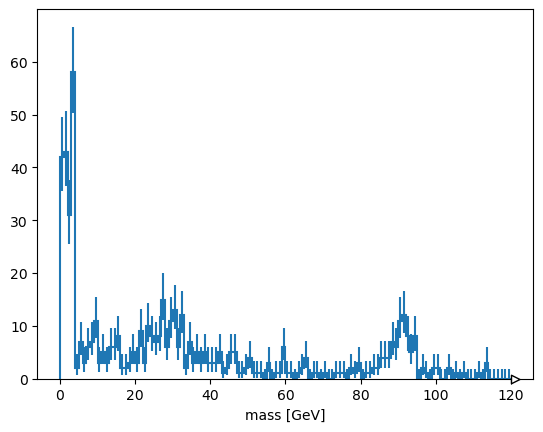

In [98]:
muons = ntuple.arrays(entry_stop=1_000)
cut = muons["nMuon"] == 2

pt0 = muons["Muon_pt", cut, 0]
pt1 = muons["Muon_pt", cut, 1]
eta0 = muons["Muon_eta", cut, 0]
eta1 = muons["Muon_eta", cut, 1]
phi0 = muons["Muon_phi", cut, 0]
phi1 = muons["Muon_phi", cut, 1]

import numpy as np

mass = np.sqrt(2 * pt0 * pt1 * (np.cosh(eta0 - eta1) - np.cos(phi0 - phi1)))

import hist

masshist = hist.Hist(hist.axis.Regular(120, 0, 120, label="mass [GeV]"))
masshist.fill(mass)
masshist.plot()

That worked (there's a Z peak). Now to do this over the whole file, we should be more careful about what we're reading,

In [99]:
ntuple.keys(filter_name=["nMuon", "/Muon_(pt|eta|phi)/"])

['nMuon', 'Muon_pt', 'Muon_eta', 'Muon_phi']

and accumulate data gradually with [uproot.TTree.iterate](https://uproot.readthedocs.io/en/latest/uproot.behaviors.TTree.TTree.html#iterate). This handles the `entry_start`/`entry_stop` in a loop.

0.048727
0.098243
0.14529
0.195486
0.243584
0.292242
0.340502
0.387927
0.436495
0.486714


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x16562fcb0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

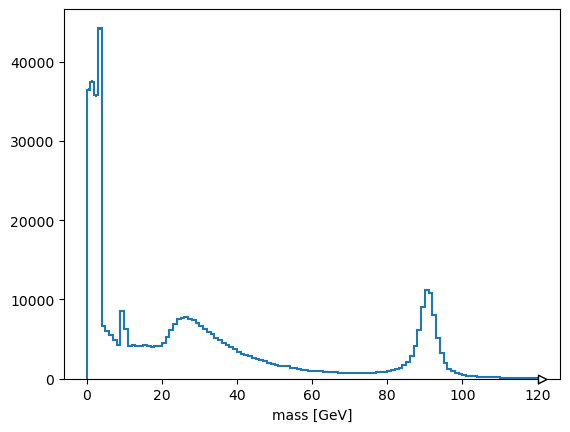

In [100]:
masshist = hist.Hist(hist.axis.Regular(120, 0, 120, label="mass [GeV]"))

for muons in ntuple.iterate(filter_name=["nMuon", "/Muon_(pt|eta|phi)/"], step_size=100_000, entry_stop=1_000_000):
    cut = muons["nMuon"] == 2
    pt0 = muons["Muon_pt", cut, 0]
    pt1 = muons["Muon_pt", cut, 1]
    eta0 = muons["Muon_eta", cut, 0]
    eta1 = muons["Muon_eta", cut, 1]
    phi0 = muons["Muon_phi", cut, 0]
    phi1 = muons["Muon_phi", cut, 1]
    mass = np.sqrt(2 * pt0 * pt1 * (np.cosh(eta0 - eta1) - np.cos(phi0 - phi1)))
    masshist.fill(mass)
    print(masshist.sum() / ntuple.num_entries)

masshist.plot()

## Getting data into NumPy or Pandas

In all of the above examples, the `array`, `arrays`, and `iterate` methods return Awkward Arrays. The Awkward Array library is useful for exactly this kind of data (jagged arrays: more in the next lesson), but you might be working with libraries that only recognize NumPy arrays or Pandas DataFrames.

Use `library="np"` or `library="pd"` to get NumPy or Pandas, respectively.

In [101]:
ntuple["nMuon"].array(library="np", entry_stop=1_000)

array([ 2,  2,  1,  4,  4,  3,  2,  2,  2,  2,  2,  2,  6,  3,  2,  1,  2,
        2,  2,  2,  2,  5,  3,  3,  4,  2,  2,  2,  3,  2,  0,  2,  3,  2,
        3,  3,  2,  2,  2,  2,  2,  2,  3,  2,  3,  1,  3,  2,  5,  3,  1,
        5,  2,  2,  3,  2,  1,  2,  3,  2,  3,  2,  1,  1,  5,  2,  0,  2,
        1,  2,  1,  4,  2,  2,  2,  2,  4,  2,  1,  1,  2,  1,  2,  1,  1,
        2,  1,  5,  2,  1,  3,  3,  2,  2,  3,  4,  1,  2,  0,  2,  2,  2,
        2,  2,  1,  2,  2,  2,  4,  3,  2,  3,  2,  7,  2,  2,  2,  3,  4,
        2,  1,  0,  2,  3,  2,  2,  3,  2,  2,  1,  2,  2,  1,  4,  2,  2,
        5,  2,  3,  2,  2,  3,  5,  2,  1,  7,  3,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  4,  2,  3,  2,  0,  2,  1,  3,  2,  4,  5,  2,
        2,  2,  5,  2,  3,  2,  2,  3,  2,  4,  2,  1,  3,  0,  2,  2,  3,
        4,  2,  3,  3,  6,  2,  2,  2,  2,  2,  6,  2,  2,  1,  2,  2,  3,
        3,  2,  2,  2,  2,  2,  4,  2,  4,  2,  2,  2,  2,  4,  2,  2,  2,
        2,  2,  3,  2,  2

In [102]:
ntuple.arrays(library="pd", entry_stop=1_000)

,nMuon,Muon_pt,Muon_eta,Muon_phi,Muon_mass,Muon_charge
0,2,"[10.763696670532227, 15.736522674560547]","[1.0668272972106934, -0.563786506652832]","[-0.03427272289991379, 2.5426154136657715]","[0.10565836727619171, 0.10565836727619171]","[-1, -1]"
1,2,"[10.538490295410156, 16.327096939086914]","[-0.42778006196022034, 0.34922507405281067]","[-0.2747921049594879, 2.539781332015991]","[0.10565836727619171, 0.10565836727619171]","[1, -1]"
2,1,[3.2753264904022217],[2.210855484008789],[-1.2234135866165161],[0.10565836727619171],[1]
3,4,"[11.429154396057129, 17.634033203125, 9.624728...","[-1.5882395505905151, -1.7511844635009766, -1....","[-2.0773041248321533, 0.25135836005210876, -2....","[0.10565836727619171, 0.10565836727619171, 0.1...","[1, 1, 1, 1]"
4,4,"[3.2834417819976807, 3.64400577545166, 32.9112...","[-2.1724836826324463, -2.18253493309021, -1.12...","[-2.3700082302093506, -2.3051390647888184, -0....","[0.10565836727619171, 0.10565836727619171, 0.1...","[-1, -1, 1, 1]"
...,...,...,...,...,...,...
995,3,"[22.06355094909668, 12.945415496826172, 13.397...","[1.9658242464065552, -0.1912732571363449, -0.1...","[0.3269919753074646, -2.6377272605895996, -2.6...","[0.10565836727619171, 0.10565836727619171, 0.1...","[1, -1, -1]"
996,2,"[10.052776336669922, 4.336074352264404]","[0.832908034324646, 1.9521838426589966]","[-1.5373767614364624, -0.07796303927898407]","[0.10565836727619171, 0.10565836727619171]","[-1, 1]"
997,3,"[4.36127233505249, 15.089585304260254, 12.3592...","[1.0476676225662231, -0.675965428352356, 0.749...","[2.1066837310791016, -2.155407190322876, 2.129...","[0.10565836727619171, 0.10565836727619171, 0.1...","[1, 1, -1]"
998,4,"[17.660253524780273, 4.613911151885986, 8.7928...","[0.5870140194892883, 1.287946343421936, 0.4992...","[-0.13344137370586395, -2.3934242725372314, -0...","[0.10565836727619171, 0.10565836727619171, 0.1...","[-1, -1, -1, -1]"


NumPy is great for non-jagged data like the `"nMuon"` branch, but it has to represent an unknown number of muons per event as an array of NumPy arrays (i.e. Python objects).

Pandas can be made to represent multiple particles per event by putting this structure in a [pd.MultiIndex](https://pandas.pydata.org/pandas-docs/stable/user_guide/advanced.html), but not when the DataFrame contains more than one particle type (e.g. muons *and* electrons). Use separate DataFrames for these cases. If it helps, note that there's another route to DataFrames: by reading the data as an Awkward Array and calling [ak.to_pandas](https://awkward-array.readthedocs.io/en/latest/_auto/ak.to_pandas.html) on it. (Some methods use more memory than others, and I've found Pandas to be unusually memory-intensive.)

Or use Awkward Arrays!